<a href="https://colab.research.google.com/github/Doan-Truc/Doan-Truc/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

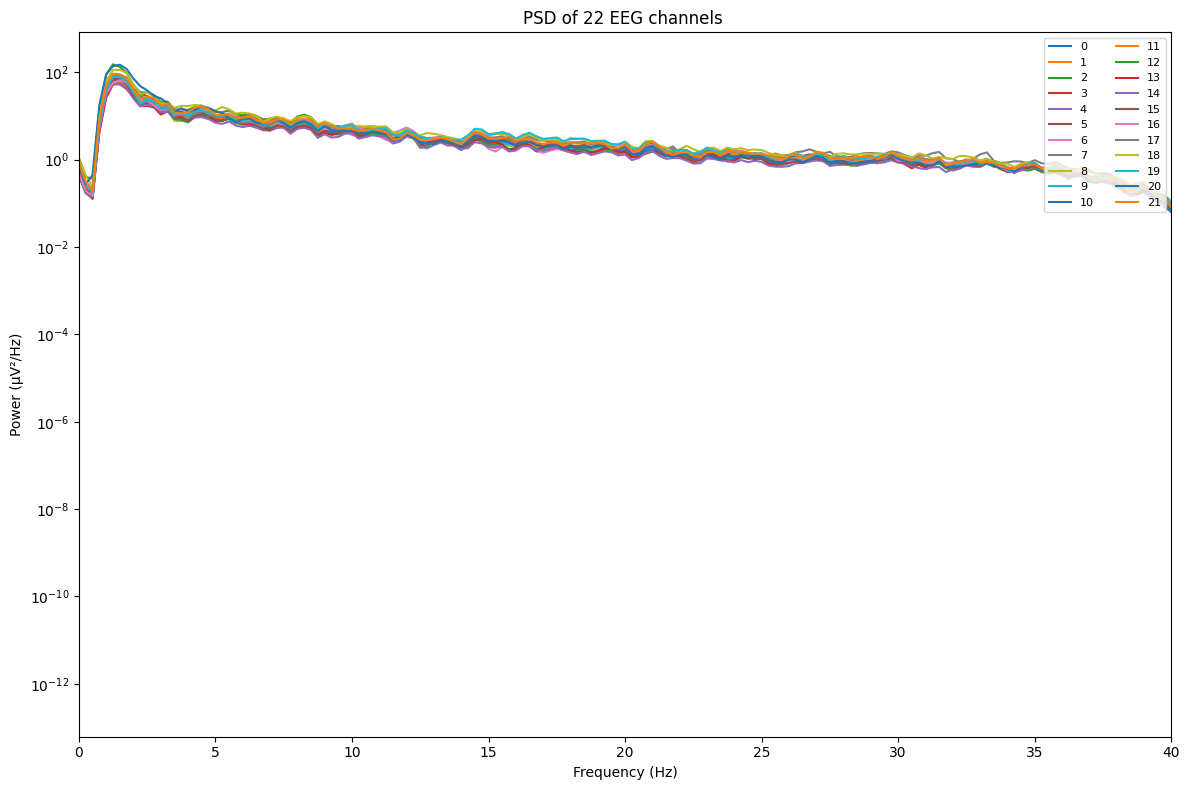

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch
import matplotlib.pyplot as plt

# 1. Load dữ liệu
# -------------------------
# Giả sử file CSV có dạng: mỗi cột = 1 kênh EEG, mỗi hàng = 1 sample
data = pd.read_csv("/content/Run5_Raw Signals.csv")
eeg = data.values   # (samples, channels)
channel_names = data.columns.tolist()

fs = 128  # sampling rate

# -------------------------
# 2. Preprocessing
# -------------------------
# Band-pass 1–40 Hz
def bandpass_filter(data, fs, lowcut=1, highcut=40, order=5):
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return sosfiltfilt(sos, data, axis=0)

eeg_bp = bandpass_filter(eeg, fs)

# Notch 50 Hz
b_notch, a_notch = iirnotch(50.0, 30.0, fs)
eeg_clean = filtfilt(b_notch, a_notch, eeg_bp, axis=0)

# -------------------------
# 3. PSD bằng Welch cho từng kênh
# -------------------------
psd_all = {}
freqs = None

for idx, ch in enumerate(channel_names):
    f, Pxx = welch(eeg_clean[:, idx], fs=fs, nperseg=512)
    psd_all[ch] = Pxx
    if freqs is None:
        freqs = f

# -------------------------
# 4. Plot line PSD của tất cả kênh
# -------------------------
plt.figure(figsize=(12,8))

for ch in channel_names:
    plt.semilogy(freqs, psd_all[ch], label=ch)

plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title("PSD of 22 EEG channels ")
plt.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


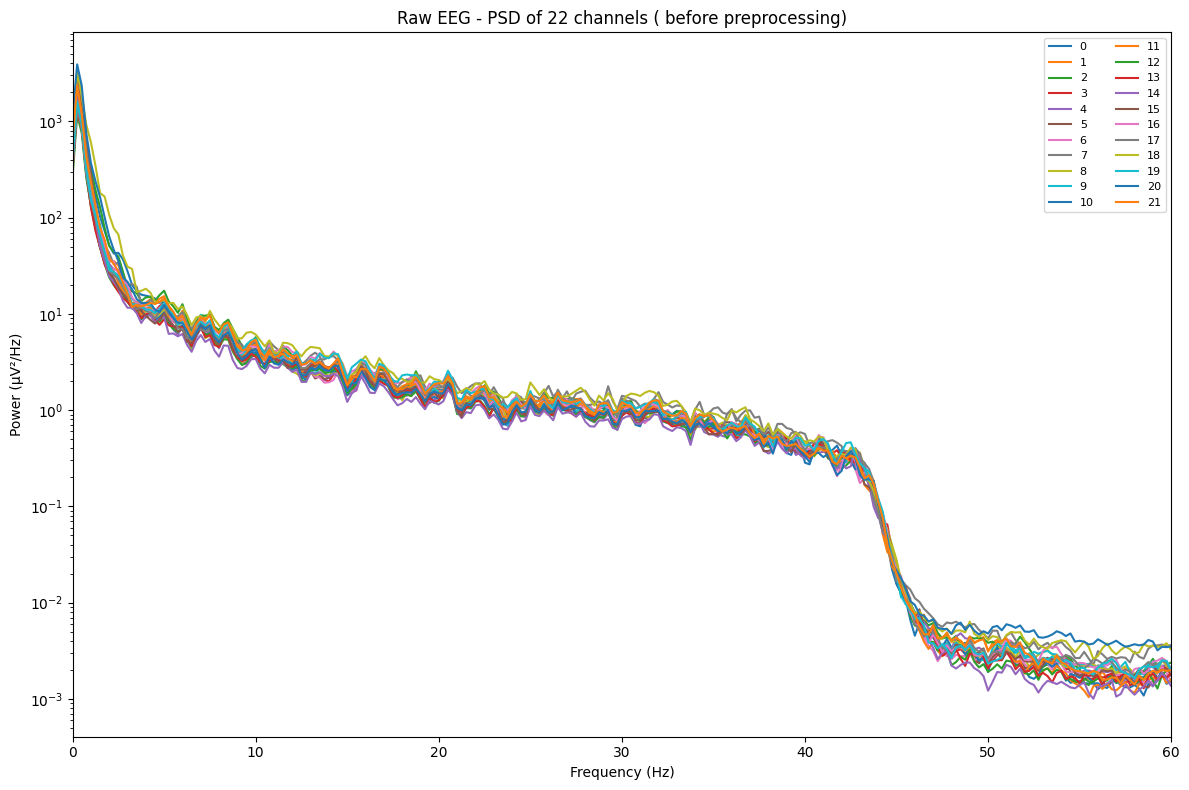

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

# -------------------------
# 1. Load raw EEG từ file CSV
# -------------------------
data = pd.read_csv("/content/Run4_Raw Signals.csv")
eeg_raw = data.values   # (samples, channels)
channel_names = data.columns.tolist()

fs = 128  # sampling rate (Hz)

# -------------------------
# 2. Tính PSD cho tất cả kênh (raw)
# -------------------------
psd_all = {}
freqs = None

for idx, ch in enumerate(channel_names):
    f, Pxx = welch(eeg_raw[:, idx], fs=fs, nperseg=512)
    psd_all[ch] = Pxx
    if freqs is None:
        freqs = f

# -------------------------
# 3. Vẽ line plot chồng 22 kênh
# -------------------------
plt.figure(figsize=(12, 8))
for ch in channel_names:
    plt.semilogy(freqs, psd_all[ch], label=ch)

plt.xlim(0, 60)  # mở rộng để thấy nhiễu 50 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV²/Hz)")
plt.title("Raw EEG - PSD of 22 channels ( before preprocessing)")
plt.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


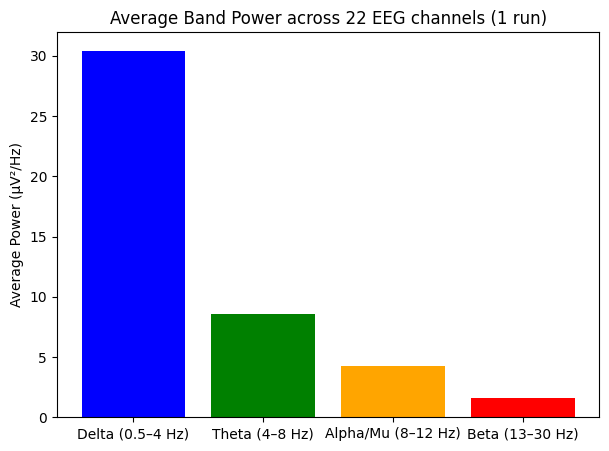

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# eeg_clean: dữ liệu EEG sau preprocessing (samples x channels)
# fs: sampling rate = 128 Hz
# channel_names: list tên kênh (22 kênh)

# -------------------------
# 1. Định nghĩa frequency bands
# -------------------------
bands = {
    "Delta (0.5–4 Hz)": (0.5, 4),
    "Theta (4–8 Hz)": (4, 8),
    "Alpha/Mu (8–12 Hz)": (8, 12),
    "Beta (13–30 Hz)": (13, 30),
}

# -------------------------
# 2. Hàm tính bandpower
# -------------------------
def bandpower(signal, fs, fmin, fmax):
    f, Pxx = welch(signal, fs=fs, nperseg=512)
    idx = np.logical_and(f >= fmin, f <= fmax)
    return np.mean(Pxx[idx])

# -------------------------
# 3. Tính power trung bình trên tất cả kênh
# -------------------------
band_means = {}
for band_name, (fmin, fmax) in bands.items():
    values = []
    for ch in range(eeg_clean.shape[1]):  # duyệt 22 kênh
        values.append(bandpower(eeg_clean[:, ch], fs, fmin, fmax))
    band_means[band_name] = np.mean(values)

# -------------------------
# 4. Vẽ bar chart
# -------------------------
plt.figure(figsize=(7,5))
plt.bar(band_means.keys(), band_means.values(), color=['blue','green','orange','red'])
plt.ylabel("Average Power (µV²/Hz)")
plt.title("Average Band Power across 22 EEG channels (1 run)")
plt.show()


In [2]:
!git clone https://github.com/Doan-Truc/Prethesis

Cloning into 'Prethesis'...
fatal: could not read Username for 'https://github.com': No such device or address
